In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

HOME = os.environ['HOME']
TEUFEL_DIR = HOME+'/Programming/TEUFEL'

sys.path.append(TEUFEL_DIR+'/scripts')
import teufel
import sdds
import h5py

import scipy.constants as sc
mec2 = sc.m_e*sc.c**2 / sc.e

In [2]:
!ls

Chicane_testing.ipynb		     csr_dali_u300_obs_10m.sdds
CSR2d_testing.ipynb		     CSR_InteractionField.ipynb
csr_dali_u300_beamlog.sdds	     LienardWiechert.ipynb
csr_dali_u300_interaction_slices.h5  MIR_superradiance.ipynb


In [3]:
# open the file
hdf = h5py.File('csr_dali_u300_interaction_slices.h5', "r")
print(hdf)
print(hdf.keys())

<HDF5 file "csr_dali_u300_interaction_slices.h5" (mode r)>
<KeysViewHDF5 ['Slices', 'Snapshots']>


In [4]:
snaps = hdf['Snapshots']
print(snaps)
print(snaps.attrs.keys())
NoS = snaps.attrs.get('N_steps')
print(f'{NoS=}')
snap_data = np.array(snaps)
print(snap_data.shape)
print()

slices = hdf['Slices']
print(slices)
print(slices.attrs.keys())
NoSteps = slices.attrs.get('N_steps')
NoSlices = slices.attrs.get('N_slices')
print(f'{NoSteps=}   {NoSlices=}')
slice_data = np.array(slices)
print(slice_data.shape)
print()

hdf.close()

<HDF5 dataset "Snapshots": shape (2000, 7), type "<f8">
<KeysViewHDF5 ['N_steps']>
NoS=2000
(2000, 7)

<HDF5 dataset "Slices": shape (2000, 20, 13), type "<f8">
<KeysViewHDF5 ['N_slices', 'N_steps']>
NoSteps=2000   NoSlices=20
(2000, 20, 13)



t = (0, 9.168426e-09) s
z = (-1.032425e-06, 2.74626) m


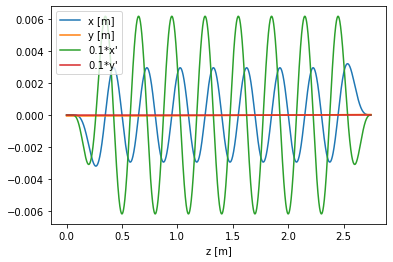

In [5]:
t = snap_data[:,0]
print(f't = ({np.min(t):.7g}, {np.max(t):.7g}) s')

x = snap_data[:,1]
y = snap_data[:,2]
z = snap_data[:,3]
print(f'z = ({np.min(z):.7g}, {np.max(z):.7g}) m')

xp = snap_data[:,4] / snap_data[:,6]
yp = snap_data[:,5] / snap_data[:,6]

plt.plot(z,x, label='x [m]')
plt.plot(z,y, label='y [m]')
plt.plot(z,0.1*xp, label="0.1*x'")
plt.plot(z,0.1*yp, label="0.1*y'")
plt.xlabel('z [m]')
plt.legend()
plt.show()

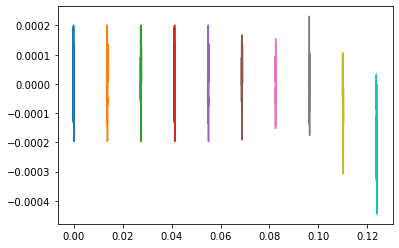

In [6]:
for i in range(0,100,10):
    slc = slice_data[i,:,:]
    z_list = slc[:,5]
    x_list = slc[:,3]
    plt.plot(z_list,x_list)
plt.show()

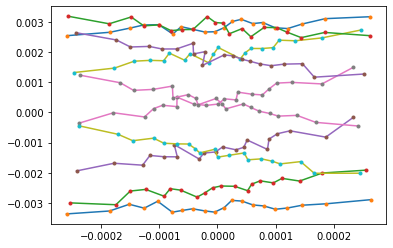

In [8]:
for i in range(200,400,20):
    slc = slice_data[i,:,:]
    z_list = slc[:,5]
    z_center = snap_data[i,3]
    x_list = slc[:,3]
    plt.plot(z_list-z_center,x_list)
    plt.plot(z_list-z_center,x_list, '.')
plt.show()

In [9]:
slice_s_min = slice_data[200,:,0]
slice_s_max = slice_data[200,:,1]
print(slice_s_min)
print(slice_s_max)
slice_lengths = slice_s_max - slice_s_min
print(slice_lengths)
print(slice_lengths.sum())

[-3.94006412e-04 -2.10124276e-04 -1.61915237e-04 -1.40385855e-04
 -1.13722046e-04 -8.90596633e-05 -7.20042503e-05 -5.26974219e-05
 -3.27198974e-05 -1.45838747e-05  2.18934445e-06  2.06644706e-05
  3.38179234e-05  5.19306744e-05  7.16549172e-05  8.89768095e-05
  1.08373871e-04  1.31568337e-04  1.64416660e-04  2.24616373e-04]
[-2.11151376e-04 -1.61960274e-04 -1.40739000e-04 -1.13916661e-04
 -8.94843447e-05 -7.22758677e-05 -5.27251911e-05 -3.29600557e-05
 -1.49838676e-05  1.96715634e-06  2.06007783e-05  3.36435644e-05
  5.19200771e-05  7.01816824e-05  8.89383873e-05  1.08360470e-04
  1.30656607e-04  1.62852059e-04  2.23873783e-04  4.68314075e-04]
[1.82855035e-04 4.81640018e-05 2.11762364e-05 2.64691942e-05
 2.42377010e-05 1.67837956e-05 1.92790592e-05 1.97373662e-05
 1.77360298e-05 1.65510310e-05 1.84114338e-05 1.29790938e-05
 1.81021537e-05 1.82510079e-05 1.72834701e-05 1.93836607e-05
 2.22827360e-05 3.12837218e-05 5.94571235e-05 2.43697702e-04]
0.0008541215538956819


In [10]:
slice_radii = slice_data[200,:,12]
print(slice_radii)

[0.00139186 0.00145852 0.00154535 0.00132582 0.001323   0.0013316
 0.00119399 0.0013736  0.00134024 0.00136212 0.00141797 0.00158707
 0.00126739 0.00152282 0.00133285 0.00141847 0.00115455 0.00144218
 0.00147343 0.00120219]
